In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [4]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discreminant: int
    result: str
    

In [10]:
def show_equation(state:QuadState)->QuadState:
    equation=f"{state['a']}x^2 + {state['b']}x + {state['c']} "

    return {'equation': equation}

def calculate_discreminant(state:QuadState)->QuadState:
    a=state['a']
    b=state['b']
    c=state['c']

    discreminant=state['b']**2 - 4*state['a']*state['c']

    if discreminant>0:
        result="Two distinct real roots"
    elif discreminant==0:
        result="One real root (double root)"
    else:
        result="No real roots (complex roots)"

    return {'discreminant': discreminant, 'result': result}

def real_roots(state:QuadState)->QuadState:

    root1=-state['b'] + (state['discreminant']**0.5)/(2*state['a'])
    root2=-state['b'] - (state['discreminant']**0.5)/(2*state['a'])
    result=f"Roots are {root1} and {root2}"

    return {'result': result} 

def repeated_roots(state:QuadState)->QuadState:

    root=(-state['b']/(2*state['a']))
    result=f"only repeating Root is {root} "

    return {'result': result} 

def no_real_roots(state:QuadState)->QuadState:

    result=f"No Real Roots "

    return {'result': result}

def check_condition(state:QuadState)->Literal['real_roots','repeated_roots','no_real_roots']:

    if state['discreminant']>0:
        return 'real_roots'
    elif state['discreminant']==0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'



In [11]:
graph=StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discreminant',calculate_discreminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discreminant')
graph.add_conditional_edges('calculate_discreminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)
workflow=graph.compile()

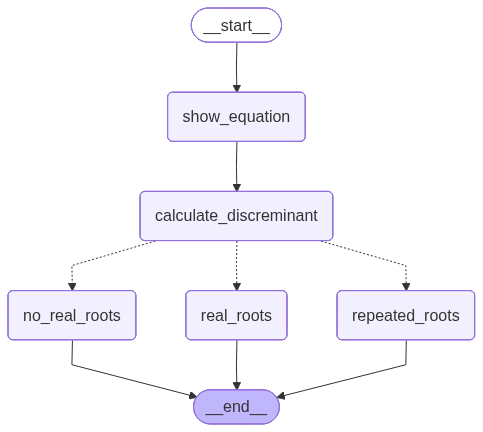

In [12]:
workflow

In [15]:
initial_State={
    'a': 2,
    'b': 4,
    'c': 2
}
final_state=workflow.invoke(initial_State)

In [16]:
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 + 4x + 2 ',
 'discreminant': 0,
 'result': 'only repeating Root is -1.0 '}